ARIMA Modeling for Apple Stock Prediction

To build an ARIMA model to predict future stock returns for Apple and evaluate its performance in capturing market dynamics.

Import Libraries

The required Python libraries were imported to handle data processing, visualization, model building, and evaluation of prediction performance.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Data Loading and Preparation

The stock dataset was loaded and the date column was converted into a datetime format and set as the index to ensure proper time-series ordering.

In [11]:
df = pd.read_csv("../../data/Apple.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close  Adj Close       Volume
Date                                                          
2015-01-02  27.85  27.86  26.84  27.33      24.21  212,818,400
2015-01-05  27.07  27.16  26.35  26.56      23.53  257,142,000
2015-01-06  26.64  26.86  26.16  26.57      23.53  263,188,400
2015-01-07  26.80  27.05  26.67  26.94      23.86  160,423,600
2015-01-08  27.31  28.04  27.17  27.97      24.78  237,458,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [12]:
df = df.resample('W-FRI').last() 
 
df['Return'] = df['Close'].pct_change() 
df = df.dropna()

Feature Engineering

Additional features such as lagged returns, moving averages, and volatility were created to help the model capture temporal patterns and market behavior more effectively.


In [13]:
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 


Create Target Variables 

Future return targets were defined for both short-term (1-week ahead) and medium-term (4-week ahead) forecasting to align with the project’s prediction goals. 

In [14]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna()

Train/Validation/Test Split 

The dataset was split into training, validation, and test sets based on time to simulate real-world forecasting and prevent data leakage. 

In [15]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_aapl = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test_aapl))

Train size: 104
Val size: 52
Test size: 57


Feature Selection 

Relevant features such as lag values, moving averages, and volatility were selected as inputs to improve model performance. 

In [16]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility']

Walk-Forward ARIMAX Model 

A walk-forward validation approach was implemented to train the ARIMAX model sequentially, ensuring realistic predictions by updating the model with new data at each step.

In [17]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train and Predict 

The ARIMAX model was trained on historical data and used to generate predictions for future stock returns. 

In [19]:
predictions = walk_forward_arimax(train, test_aapl, features)
print(predictions.head())

Date
2025-01-03   -0.013415
2025-01-10   -0.004725
2025-01-17   -0.029560
2025-01-24   -0.058018
2025-01-31    0.021765
Freq: W-FRI, dtype: float64


In [21]:
pred_aapl = walk_forward_arimax(train, test_aapl, features)

Model Evaluation 

The model performance was evaluated using MAE, RMSE, and directional accuracy to measure prediction error and correctness of movement direction. 

In [25]:
mae = mean_absolute_error(test_aapl['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test_aapl['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test_aapl['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 


MAE: 0.02126966359962308
RMSE: 0.026571332831759137
Directional Accuracy: 0.8070175438596491


Plot Actual vs Predicted

Actual and predicted returns were plotted to visually assess how well the model captures trends and fluctuations in the data. 

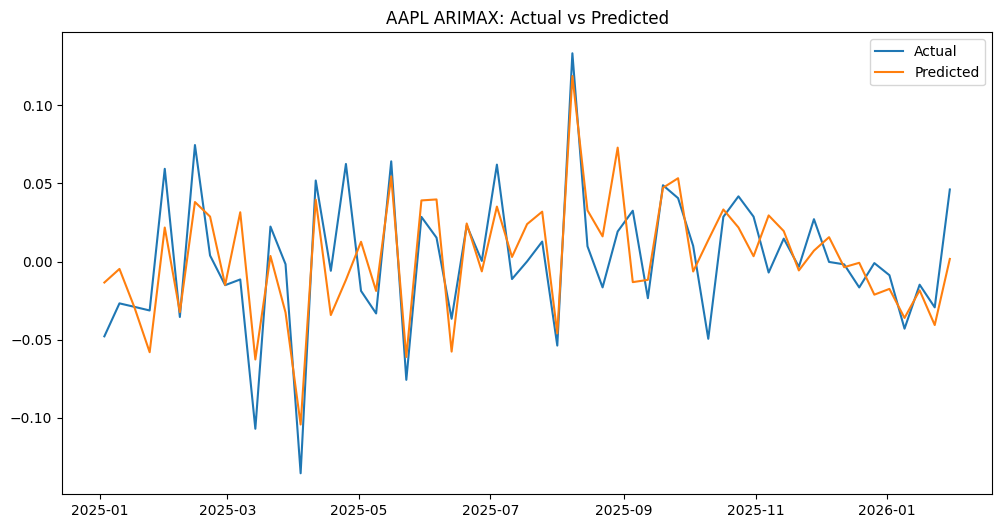

In [27]:
plt.figure(figsize=(12,6)) 
plt.plot(test_aapl['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("AAPL ARIMAX: Actual vs Predicted") 
plt.show() 

Trading Strategy 

Buy and sell signals were generated based on predicted returns to convert model outputs into actionable investment decisions. 

In [31]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test_aapl)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test_aapl['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test_aapl['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test_aapl.index) 

Backtesting 

A backtesting framework was implemented to simulate portfolio performance over time and compare the strategy against a buy-and-hold approach. 

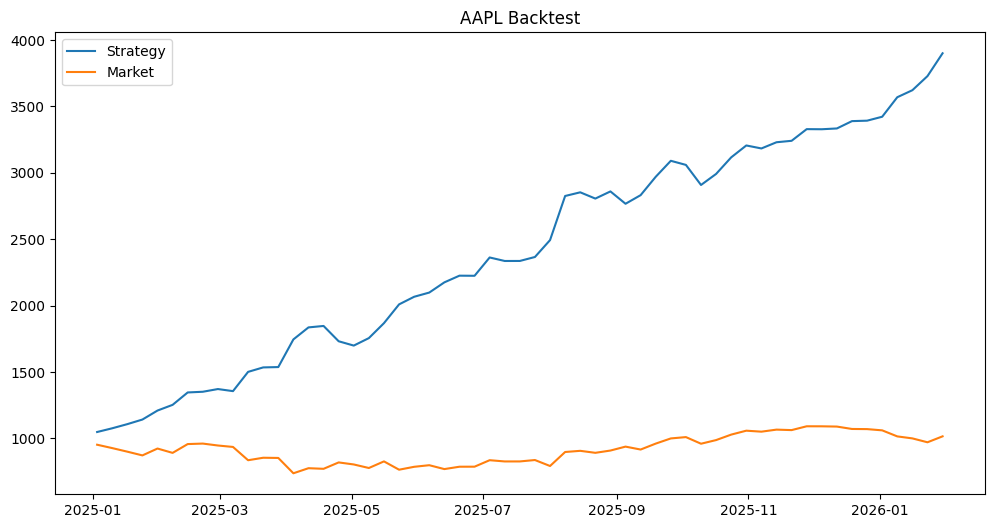

In [33]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test_aapl['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("AAPL Backtest") 
plt.show() 

 

AMAZON STOCK PREDICTION

Data Loading and Preparation

In [34]:
df = pd.read_csv("../../data/Amazon.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  15.63  15.74  15.35   15.43       15.43  55,664,000
2015-01-05  15.35  15.42  15.04   15.11       15.11  55,484,000
2015-01-06  15.11  15.15  14.62   14.76       14.76  70,380,000
2015-01-07  14.88  15.06  14.77   14.92       14.92  52,806,000
2015-01-08  15.02  15.16  14.81   15.02       15.02  61,768,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [35]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering

In [36]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 


Target

In [37]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train / Val / Test Split 

In [39]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_amzn = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test_amzn)) 

Train size: 104
Val size: 52
Test size: 57


Select Features 

In [40]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk-Forward ARIMAX 

In [41]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Predict

In [42]:
predictions = walk_forward_arimax(train, test_amzn, features)
print(predictions.head())

Date
2025-01-03   -0.004691
2025-01-10   -0.015653
2025-01-17    0.025918
2025-01-24    0.020723
2025-01-31   -0.008060
dtype: float64


In [44]:
pred_amzn = walk_forward_arimax(train, test_amzn, features)

Evaluate Model

In [45]:
mae = mean_absolute_error(test_amzn['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test_amzn['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test_amzn['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 


MAE: 0.02499384809786813
RMSE: 0.03215629170895791
Directional Accuracy: 0.7719298245614035


Plot Actual vs Predicted

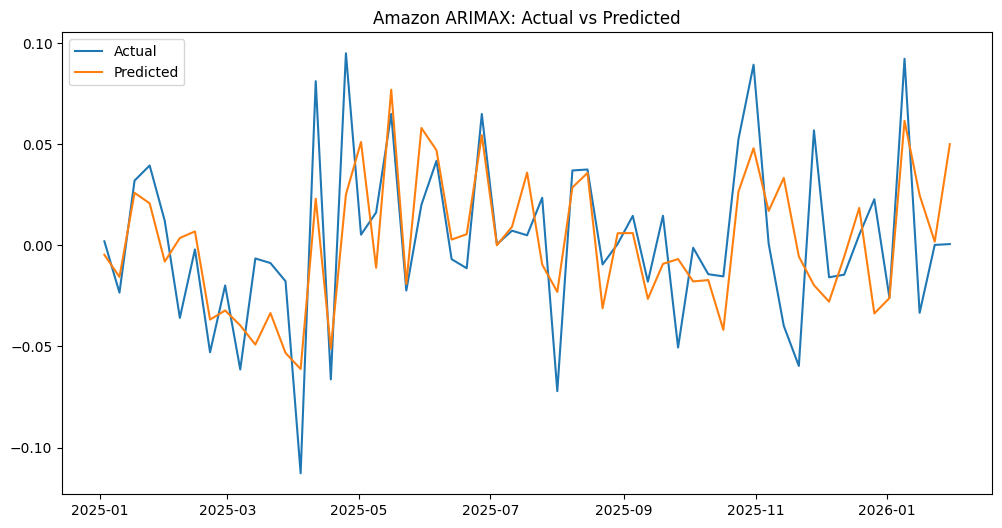

In [47]:
plt.figure(figsize=(12,6)) 
plt.plot(test_amzn['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("Amazon ARIMAX: Actual vs Predicted") 
plt.show() 

Strategy Returns

In [48]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test_amzn)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test_amzn['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test_amzn['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test_amzn.index) 

Plot Backtesting

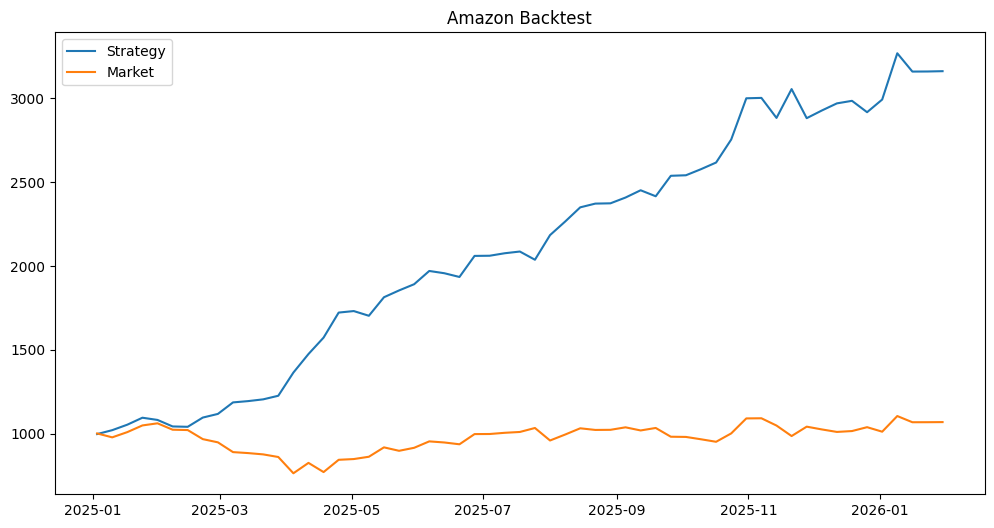

In [50]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test_amzn['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("Amazon Backtest") 
plt.show() 

GOOGLE STOCK PREDICTION

Data Loading and Preparation

In [51]:
df = pd.read_csv("../../data/google.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  26.63  26.79  26.39   26.48       26.28  26,480,000
2015-01-05  26.36  26.40  25.89   25.97       25.78  41,182,000
2015-01-06  26.02  26.06  25.28   25.33       25.14  54,456,000
2015-01-07  25.55  25.57  25.18   25.26       25.07  46,918,000
2015-01-08  25.08  25.38  24.75   25.35       25.16  73,054,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [52]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering

In [53]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna()

Target

In [54]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train / Val / Test Split 

In [56]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_googl = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test_googl)) 

Train size: 104
Val size: 52
Test size: 57


Select Features

In [57]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk Forward ArimaX

In [58]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Predict

In [59]:
predictions = walk_forward_arimax(train, test_googl, features) 
print(predictions.head())

Date
2025-01-03    0.038504
2025-01-10   -0.006960
2025-01-17    0.030612
2025-01-24    0.009690
2025-01-31    0.015549
Freq: W-FRI, dtype: float64


In [60]:
pred_googl = walk_forward_arimax(train, test_googl, features)

Evaluate Model

In [61]:
mae = mean_absolute_error(test_googl['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test_googl['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test_googl['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 
 


MAE: 0.023497348117333675
RMSE: 0.030058350149361392
Directional Accuracy: 0.7894736842105263


Plot Actual VS Predicted

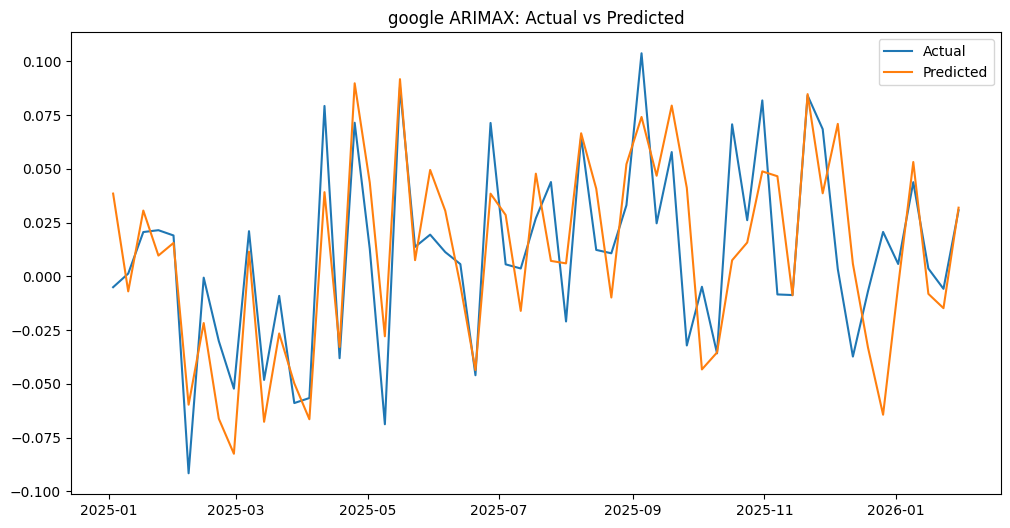

In [63]:
plt.figure(figsize=(12,6)) 
plt.plot(test_googl['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("google ARIMAX: Actual vs Predicted") 
plt.show() 

Strategy Returns

In [65]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test_googl)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test_googl['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test_googl['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test_googl.index) 

Backtesting Visualization

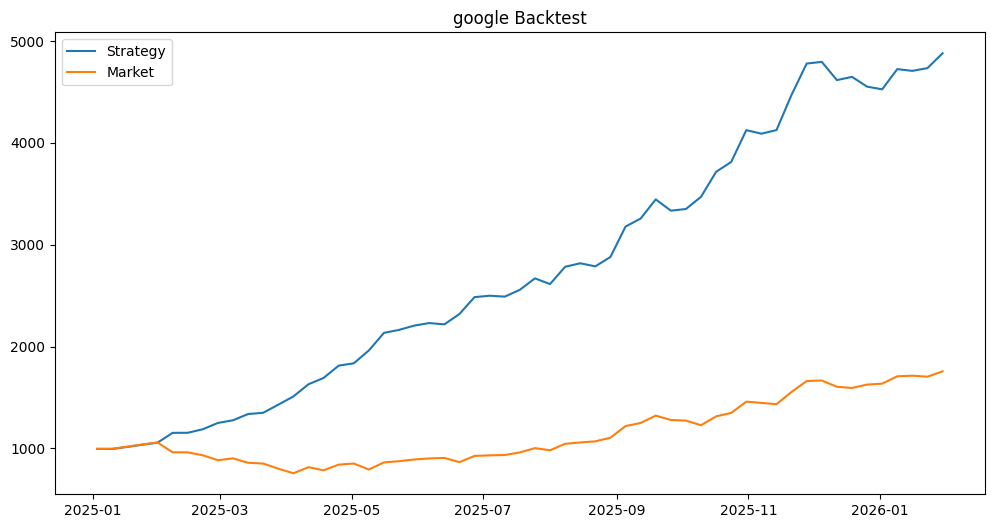

In [67]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test_googl['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("google Backtest") 
plt.show() 

MSFT STOCK PREDICTION

Data Loading and Preparation



In [68]:
df = pd.read_csv("../../data/MSFT.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  46.66  47.42  46.54   46.76       39.77  27,913,900
2015-01-05  46.37  46.73  46.25   46.33       39.40  39,673,900
2015-01-06  46.38  46.75  45.54   45.65       38.82  36,447,900
2015-01-07  45.98  46.46  45.49   46.23       39.32  29,114,100
2015-01-08  46.75  47.75  46.72   47.59       40.47  29,645,200


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [69]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering 

In [70]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 


Target

In [71]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train/ Val/ Test Split

In [72]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_msft = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test_msft)) 


Train size: 104
Val size: 52
Test size: 57


Select Features

In [73]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk Forward ArimaX

In [74]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Predict

In [75]:
predictions = walk_forward_arimax(train, test_msft, features) 
print(predictions.head())

Date
2025-01-03   -0.002506
2025-01-10   -0.022942
2025-01-17    0.004958
2025-01-24    0.008849
2025-01-31   -0.030570
Freq: W-FRI, dtype: float64


In [76]:
pred_msft = walk_forward_arimax(train, test_msft, features)

Evaluate Model

In [77]:
mae = mean_absolute_error(test_msft['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test_msft['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test_msft['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction)

MAE: 0.016852271024792434
RMSE: 0.021677995657012086
Directional Accuracy: 0.8421052631578947


Plot Actual vs Predicted

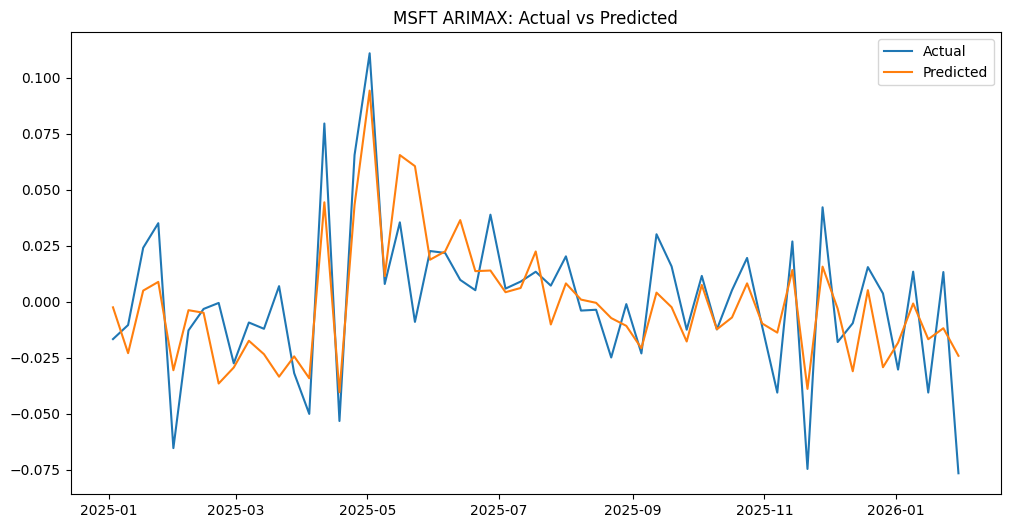

In [78]:
plt.figure(figsize=(12,6)) 
plt.plot(test_msft['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("MSFT ARIMAX: Actual vs Predicted") 
plt.show() 

Strategy Returns

In [80]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test_msft)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test_msft['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test_msft['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test_msft.index) 

Visualization Backtesting

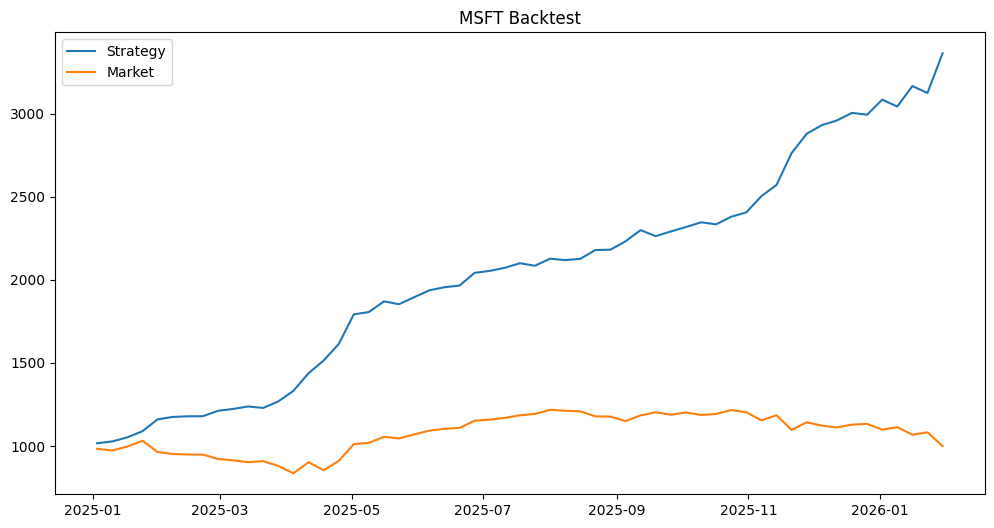

In [82]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test_msft['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("MSFT Backtest") 
plt.show() 

NVIDIA STOCK PREDICTION

Data Loading and Preparation

In [83]:
df = pd.read_csv("../../data/NVIDIA.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df.sort_index()

print(df.head())

            Open  High   Low  Close   Adj Close        Volume
Date                                                         
2015-01-02  0.50  0.51  0.50    0.50        0.48  113,680,000
2015-01-05  0.50  0.50  0.49    0.49        0.47  197,952,000
2015-01-06  0.50  0.50  0.48    0.48        0.46  197,764,000
2015-01-07  0.48  0.49  0.48    0.48        0.46  321,808,000
2015-01-08  0.48  0.50  0.48    0.50        0.48  283,780,000


Convert to Weekly Data

The daily stock data was resampled into weekly frequency using Friday closing prices to reduce noise and capture more stable trends.

In [84]:
df = df.resample('W-FRI').last()

# Debug: check what columns actually exist after resample
print(df.columns.tolist())

# Strip whitespace from column names (common culprit)
df.columns = df.columns.str.strip()

df['Return'] = df['Close'].pct_change()
df = df.dropna()

['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']


Feature Engineering 

In [85]:
# Lag features 
df['lag1'] = df['Return'].shift(1) 
df['lag2'] = df['Return'].shift(2) 
 
# Moving averages 
df['ma4'] = df['Return'].rolling(4).mean() 
df['ma8'] = df['Return'].rolling(8).mean() 
 
# Volatility 
df['volatility'] = df['Return'].rolling(4).std() 
 
df = df.dropna() 
 


Target

In [86]:
# 1-week ahead return 
df['target_1w'] = df['Return'].shift(-1) 
 
# 4-week ahead return 
df['target_4w'] = df['Return'].rolling(4).sum().shift(-4) 
 
df = df.dropna() 


Train/ Val/ Test Split

In [87]:
train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test_nvda = df[df.index >= "2025-01-01"]

print("Train size:", len(train))
print("Val size:", len(val))
print("Test size:", len(test_nvda)) 


Train size: 104
Val size: 52
Test size: 57


Select Features

In [88]:
features = ['lag1', 'lag2', 'ma4', 'ma8', 'volatility'] 


Walk Forward ArimaX Function

In [89]:
def walk_forward_arimax(train, test, features): 
     
    history_y = list(train['Return']) 
    history_x = train[features].copy() 
     
    predictions = [] 
 
    for i in range(len(test)): 
         
        model = SARIMAX( 
            history_y, 
            exog=history_x, 
            order=(1,1,1), 
            enforce_stationarity=False, 
            enforce_invertibility=False 
        ) 
         
        model_fit = model.fit(disp=False) 
         
        exog_test = test[features].iloc[i:i+1] 
         
        yhat = model_fit.forecast(steps=1, exog=exog_test).iloc[0]
        predictions.append(yhat) 
         
        # update history 
        history_y.append(test['Return'].iloc[i]) 
        history_x = pd.concat([history_x, exog_test]) 
     
    return pd.Series(predictions, index=test.index)



Train Model & Prediction

In [90]:
predictions = walk_forward_arimax(train, test_nvda, features) 
print(predictions.head())

Date
2025-01-03   -0.006122
2025-01-10   -0.015479
2025-01-17    0.006977
2025-01-24    0.034146
2025-01-31   -0.086114
Freq: W-FRI, dtype: float64


In [91]:
pred_nvda = walk_forward_arimax(train, test_nvda, features)

Evaluate Model

In [92]:
mae = mean_absolute_error(test_nvda['Return'], predictions) 
rmse = np.sqrt(mean_squared_error(test_nvda['Return'], predictions)) 
 
direction = np.mean(np.sign(predictions) == np.sign(test_nvda['Return'])) 
 
print("MAE:", mae) 
print("RMSE:", rmse) 
print("Directional Accuracy:", direction) 


MAE: 0.03309974535782508
RMSE: 0.04463415341391052
Directional Accuracy: 0.7719298245614035


Plot Actual vs Predicted

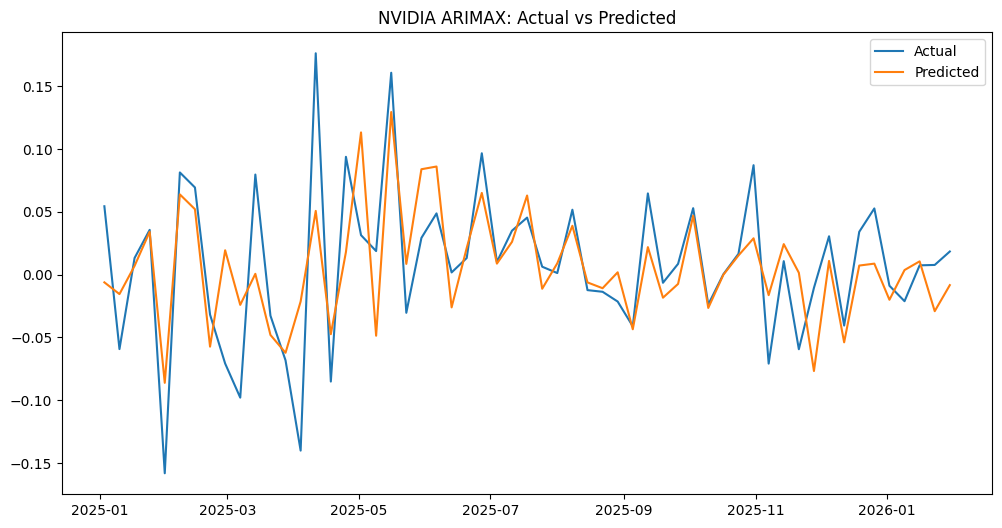

In [94]:
plt.figure(figsize=(12,6)) 
plt.plot(test_nvda['Return'], label='Actual') 
plt.plot(predictions, label='Predicted') 
plt.legend() 
plt.title("NVIDIA ARIMAX: Actual vs Predicted") 
plt.show() 

 

Strategy Returns

In [96]:
signals = np.where(predictions > 0, "BUY", "SELL") 
 
strategy_returns = [] 
 
for i in range(len(test_nvda)): 
    if signals[i] == "BUY": 
        strategy_returns.append(test_nvda['Return'].iloc[i]) 
    else: 
        strategy_returns.append(-test_nvda['Return'].iloc[i]) 
 
strategy_returns = pd.Series(strategy_returns, index=test_nvda.index) 

Plot Backtesting Results

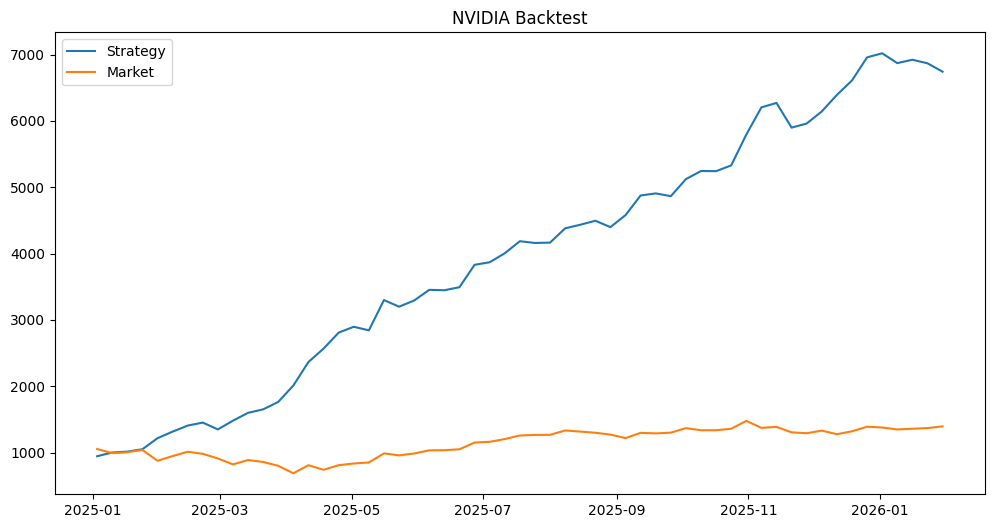

In [97]:
initial = 1000 
 
strategy_cum = (1 + strategy_returns).cumprod() * initial 
market_cum = (1 + test_nvda['Return']).cumprod() * initial 
 
plt.figure(figsize=(12,6)) 
plt.plot(strategy_cum, label="Strategy") 
plt.plot(market_cum, label="Market") 
plt.legend() 
plt.title("NVIDIA Backtest") 
plt.show() 

Combine All 5 stocks

Created one dataframe that contains predictions from all stocks 

In [101]:
pred_aapl
pred_googl
pred_msft
pred_nvda
pred_amzn   


Date
2025-01-03   -0.004691
2025-01-10   -0.015653
2025-01-17    0.025918
2025-01-24    0.020723
2025-01-31   -0.008060
2025-02-07    0.003592
2025-02-14    0.006849
2025-02-21   -0.036734
2025-02-28   -0.032227
2025-03-07   -0.039631
2025-03-14   -0.049087
2025-03-21   -0.033506
2025-03-28   -0.053240
2025-04-04   -0.061176
2025-04-11    0.023012
2025-04-18   -0.051089
2025-04-25    0.025090
2025-05-02    0.051055
2025-05-09   -0.011115
2025-05-16    0.076910
2025-05-23   -0.019121
2025-05-30    0.057975
2025-06-06    0.046931
2025-06-13    0.002797
2025-06-20    0.005478
2025-06-27    0.054423
2025-07-04    0.000002
2025-07-11    0.009138
2025-07-18    0.035907
2025-07-25   -0.009536
2025-08-01   -0.023045
2025-08-08    0.028568
2025-08-15    0.035745
2025-08-22   -0.031119
2025-08-29    0.005945
2025-09-05    0.006022
2025-09-12   -0.026490
2025-09-19   -0.009205
2025-09-26   -0.006801
2025-10-03   -0.017886
2025-10-10   -0.017198
2025-10-17   -0.041817
2025-10-24    0.026524
2025-1

Combining into One DataFrame

In [103]:
# Combine predictions
arima_predictions = pd.DataFrame({
    "AAPL": pred_aapl,
    "GOOGL": pred_googl,
    "MSFT": pred_msft,
    "NVDA": pred_nvda,
    "AMZN": pred_amzn
})

Verify

In [109]:
arima_predictions_all = predictions  # if single stock

In [110]:
print(dir())

['In', 'Out', 'SARIMAX', '_', '_101', '_98', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', '_i58', '_i59', '_i6', '_i60', '_i61', '_i62', '_i63', '_i64', '_i65', '_i66', '_i67', '_i68', '_i69', '_i7', '_i70', '_i71', '_i72', '_i73', '_i74', '_i75', '_i76', '_i77', '_i78', '_i79', '_i8', '_i80', '_i81', '_i82', '_i83', '_i84', '_i85', '_i86', '_i87', '_i88', '_i89', '_i9', '_i90', '_

In [ ]:
# 1. Split data
df.index = pd.to_datetime(df.index)

train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
val   = df[(df.index >= "2024-01-01") & (df.index < "2025-01-01")]
test  = df[df.index >= "2025-01-01"]
# 2. Generate predictions
predictions = walk_forward_arimax(train, test, features)

arima_predictions_all = predictions

print(arima_predictions_all.head())
print(arima_predictions_all.shape)

Date
2025-01-03   -0.006122
2025-01-10   -0.015479
2025-01-17    0.006977
2025-01-24    0.034146
2025-01-31   -0.086114
Freq: W-FRI, dtype: float64
(57,)


VALIDATE DATA

In [125]:
print(arima_predictions.head())
print(arima_predictions.shape)
print(arima_predictions.columns)

                AAPL     GOOGL      MSFT      NVDA      AMZN
Date                                                        
2025-01-03 -0.013415  0.038504 -0.002506 -0.006122 -0.004691
2025-01-10 -0.004725 -0.006960 -0.022942 -0.015479 -0.015653
2025-01-17 -0.029560  0.030612  0.004958  0.006977  0.025918
2025-01-24 -0.058018  0.009690  0.008849  0.034146  0.020723
2025-01-31  0.021765  0.015549 -0.030570 -0.086114 -0.008060
(57, 5)
Index(['AAPL', 'GOOGL', 'MSFT', 'NVDA', 'AMZN'], dtype='object')


Check for duplicates

In [126]:
print(arima_predictions.index.duplicated().sum())

0


Check missing values

In [127]:
print(arima_predictions.isnull().sum())


AAPL     0
GOOGL    0
MSFT     0
NVDA     0
AMZN     0
dtype: int64


Check values are NOT identical 

In [128]:
print(arima_predictions.nunique())

AAPL     57
GOOGL    57
MSFT     57
NVDA     57
AMZN     57
dtype: int64


SAVE TO CSV

In [129]:
arima_predictions.to_csv("arima_predictions.csv")

FINAL VALIDATION

In [130]:
print("Rows:", len(arima_predictions))
print("Start Date:", arima_predictions.index.min())
print("End Date:", arima_predictions.index.max())

Rows: 57
Start Date: 2025-01-03 00:00:00
End Date: 2026-01-30 00:00:00


In [146]:
import pandas as pd

FILES = {
    'AAPL': '../../data/Apple.csv',
    'MSFT': '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN': '../../data/Amazon.csv',
    'NVDA': '../../data/NVIDIA.csv'
}

data = {}

for stock, path in FILES.items():
    df = pd.read_csv(path)

    # adjust column name if needed
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

    data[stock] = df

In [147]:
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'])


Get Actual Returns

In [170]:
actual_returns = pd.DataFrame({ 
   "AAPL": test_aapl['Return'], 
   "AMZN": test_amzn['Return'],
   "GOOGL": test_googl['Return'], 
   "MSFT": test_msft['Return'], 
   "NVDA": test_nvda['Return'] 
})

Get Best Stock

In [156]:
print(len(all_predictions))

0


In [158]:
print(all_predictions)
print(len(all_predictions))

[]
0


In [159]:
print(f"Processing {stock}")

Processing AAPL


In [161]:
all_predictions = []

for stock, df in data.items():
    try:
        print(f"Running {stock}")

        df.index = pd.to_datetime(df.index)

        df['Return'] = df['Close'].pct_change()
        df['lag1'] = df['Return'].shift(1)
        df['lag2'] = df['Return'].shift(2)
        df['ma4'] = df['Return'].rolling(4).mean()
        df['ma8'] = df['Return'].rolling(8).mean()
        df['volatility'] = df['Return'].rolling(8).std()

        df = df.dropna()

        train = df[(df.index >= "2022-01-01") & (df.index < "2024-01-01")]
        test  = df[df.index >= "2025-01-01"]

        predictions = walk_forward_arimax(train, test, features)

        print(f"{stock} predictions length:", len(predictions))

        predictions.name = stock
        all_predictions.append(predictions)

    except Exception as e:
        print(f" Error in {stock}: {e}")

Running AAPL
AAPL predictions length: 281
Running MSFT
 Error in MSFT: 'Close'
Running GOOGL
 Error in GOOGL: 'Close'
Running AMZN
 Error in AMZN: 'Close'
Running NVDA
 Error in NVDA: 'Close'


In [162]:
print(len(test))

281


In [163]:
len(all_predictions) > 0

True

In [164]:
arima_predictions_all = pd.concat(all_predictions, axis=1)

In [165]:
print(len(all_predictions))
print(data.keys())

1
dict_keys(['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'])


In [166]:
top_stock = arima_predictions_all.idxmax(axis=1)
print(top_stock.head())

Date
2026-02-17    AAPL
2026-02-13    AAPL
2026-02-12    AAPL
2026-02-11    AAPL
2026-02-10    AAPL
dtype: object


Strategy Returns

In [172]:
common_dates = top_stock.index.intersection(actual_returns.index)

top_stock = top_stock.loc[common_dates]
actual_returns = actual_returns.loc[common_dates]

In [173]:
strategy_returns = []

for i in range(len(top_stock)):
    stock = top_stock.iloc[i]
    date = top_stock.index[i]

    if date in actual_returns.index:
        ret = actual_returns.loc[date, stock]
        strategy_returns.append(ret)
    else:
        strategy_returns.append(0)  # or np.nan

Backtesting

In [177]:
strategy_returns = pd.Series(strategy_returns, index=top_stock.index)

In [178]:
print(type(strategy_returns))

<class 'pandas.core.series.Series'>


In [179]:
initial = 1000

strategy_returns = strategy_returns.fillna(0)

strategy_cum = (1 + strategy_returns).cumprod() * initial
market_cum = (1 + actual_returns.mean(axis=1)).cumprod() * initial

Plot Results

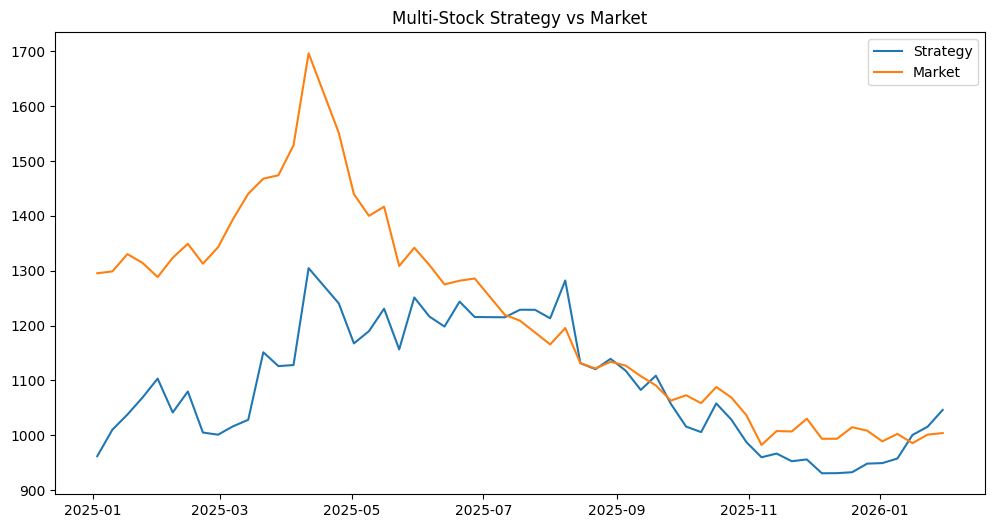

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(strategy_cum, label="Strategy")
plt.plot(market_cum, label="Market")

plt.legend()
plt.title("Multi-Stock Strategy vs Market")
plt.show()

Ranking Accuracy

In [187]:
common_dates = arima_predictions_all.index.intersection(actual_returns.index)

arima_predictions_all = arima_predictions_all.loc[common_dates]
actual_returns = actual_returns.loc[common_dates]

In [188]:
arima_predictions_all = arima_predictions_all.dropna()
actual_returns = actual_returns.loc[arima_predictions_all.index]

In [189]:
correct = 0
total = 0

for date in arima_predictions_all.index:
    try:
        pred_best = arima_predictions_all.loc[date].idxmax()
        actual_best = actual_returns.loc[date].idxmax()

        if pred_best == actual_best:
            correct += 1

        total += 1

    except Exception:
        continue

ranking_accuracy = correct / total
print("Ranking Accuracy:", ranking_accuracy)

Ranking Accuracy: 0.2


Combined predictions from multiple stocks into a unified framework, enabling dynamic ranking of assets and evaluation through backtesting and ranking accuracy metrics. 

EVALUATING ALL STOCKS TOGETHER

In [190]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

Prediction & Actual values Dictionary

In [191]:
predictions_dict = {
    "AAPL": pred_aapl,
    "GOOGL": pred_googl,
    "MSFT": pred_msft,
    "NVDA": pred_nvda,
    "AMZN": pred_amzn
}

actual_dict = {
    "AAPL": test_aapl['Return'],
    "GOOGL": test_googl['Return'],
    "MSFT": test_msft['Return'],
    "NVDA": test_nvda['Return'],
    "AMZN": test_amzn['Return']
}


Claculate Metrics

In [192]:
results = []

for stock in predictions_dict:
    
    pred = predictions_dict[stock]
    actual = actual_dict[stock]
    
    # Align indices (VERY IMPORTANT)
    pred, actual = pred.align(actual, join='inner')
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    directional_accuracy = np.mean(
        (np.sign(pred) == np.sign(actual)).astype(int)
    )
    
    results.append({
        "Stock": stock,
        "MAE": round(mae, 5),
        "RMSE": round(rmse, 5),
        "Directional Accuracy": round(directional_accuracy, 3)
    })


Convert to DataFrame

In [193]:
results_df = pd.DataFrame(results)

print(results_df)

   Stock      MAE     RMSE  Directional Accuracy
0   AAPL  0.02127  0.02657                 0.807
1  GOOGL  0.02350  0.03006                 0.789
2   MSFT  0.01685  0.02168                 0.842
3   NVDA  0.03310  0.04463                 0.772
4   AMZN  0.02499  0.03216                 0.772


Visualization of model performance across stocks shows that predictive accuracy varies significantly, with more stable stocks achieving higher directional accuracy while highly volatile stocks exhibit larger prediction errors. 

ARIMA Model Performance Across Stocks

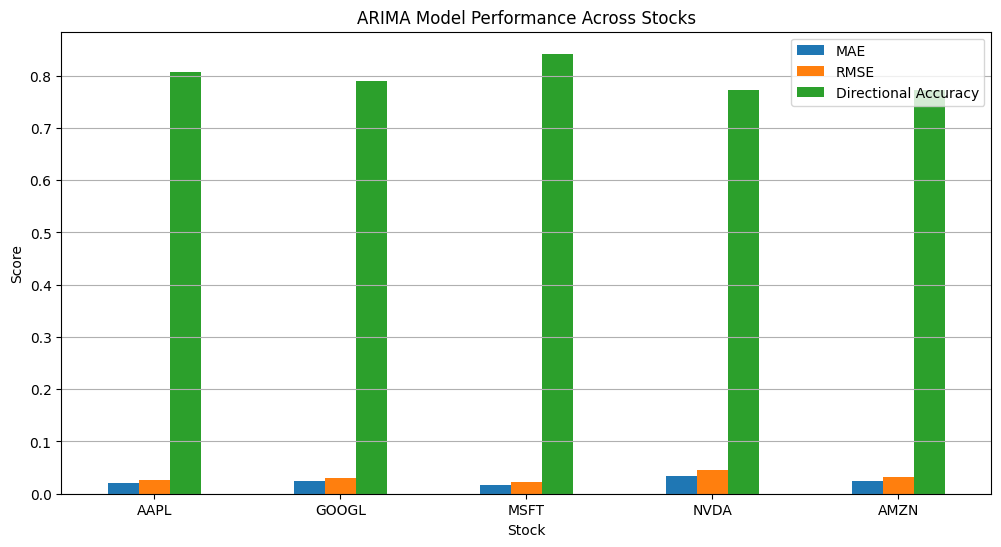

In [194]:
import matplotlib.pyplot as plt 
 
# Set index 
results_df.set_index('Stock', inplace=True) 
 
# Plot 
results_df.plot(kind='bar', figsize=(12,6)) 
 
plt.title("ARIMA Model Performance Across Stocks") 
plt.ylabel("Score") 
plt.xticks(rotation=0) 
plt.grid(axis='y') 
 
plt.legend() 
plt.show() 


Separate Graph

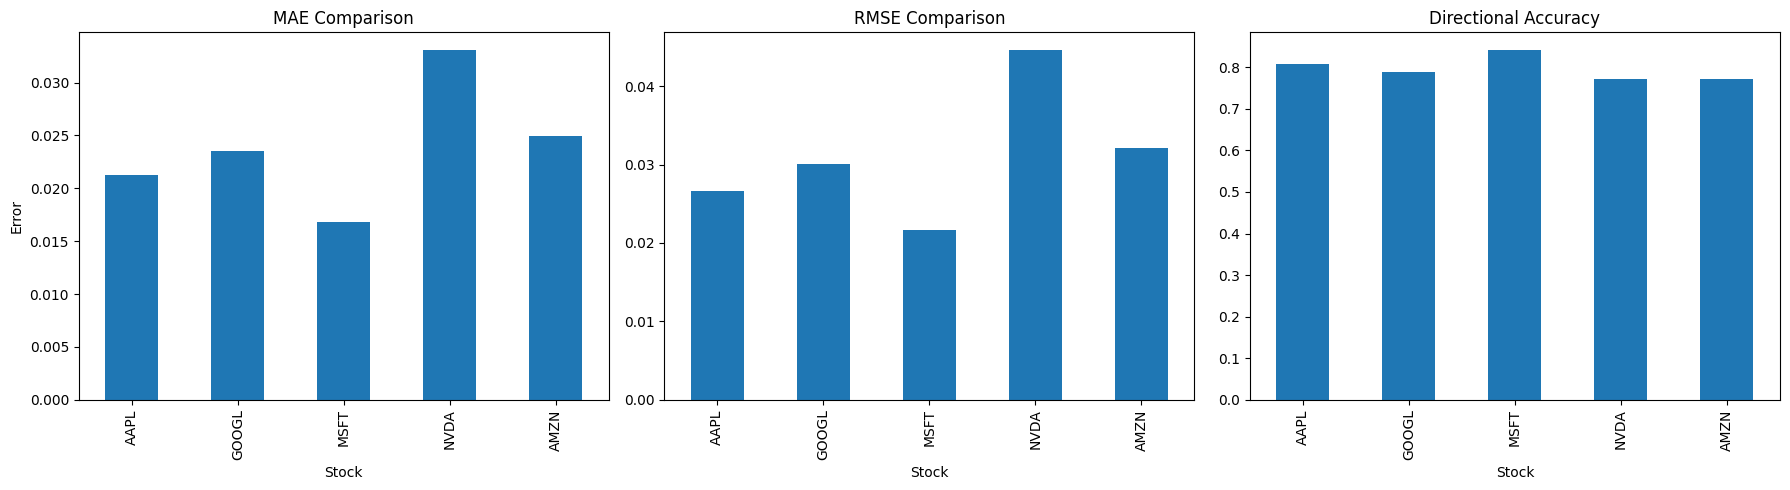

In [195]:
fig, axes = plt.subplots(1, 3, figsize=(18,5)) 
 
# MAE 
results_df['MAE'].plot(kind='bar', ax=axes[0]) 
axes[0].set_title("MAE Comparison") 
axes[0].set_ylabel("Error") 
 
# RMSE 
results_df['RMSE'].plot(kind='bar', ax=axes[1]) 
axes[1].set_title("RMSE Comparison") 
 
# Directional Accuracy 
results_df['Directional Accuracy'].plot(kind='bar', ax=axes[2]) 
axes[2].set_title("Directional Accuracy") 
 
plt.tight_layout() 
plt.show() 


Highlight Best Stock

In [196]:
best_stock = results_df['Directional Accuracy'].idxmax() 
 
print("Best Performing Stock:", best_stock) 


Best Performing Stock: MSFT


Performance Trend Across Stocks

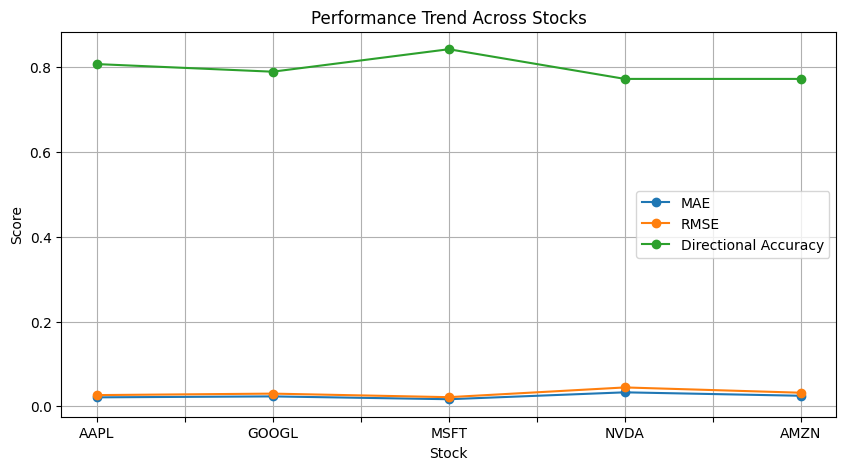

In [197]:
results_df.plot(marker='o', figsize=(10,5)) 
 
plt.title("Performance Trend Across Stocks") 
plt.ylabel("Score") 
plt.grid() 
 
plt.show() 


Ranking System For Best Sock Per Week

In [198]:
predictions_all   # DataFrame (all stock predictions)
actual_returns    # DataFrame (all actual returns)

,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2026-01-30,0.046122,0.000585,0.030752,-0.076532,0.018437
2026-01-23,-0.029312,0.000167,-0.005782,0.013243,0.007732
2026-01-16,-0.014805,-0.033390,0.003646,-0.040519,0.007411
2026-01-09,-0.042950,0.092185,0.043828,0.013406,-0.021128
2026-01-02,-0.008742,-0.025890,0.005773,-0.030284,-0.008818
2025-12-26,-0.000987,0.022740,0.020673,0.003684,0.052710
2025-12-19,-0.016566,0.005128,-0.006887,0.015443,0.034110
2025-12-12,-0.001794,-0.014551,-0.037290,-0.009583,-0.040513
2025-12-05,-0.000251,-0.015822,0.003404,-0.017987,0.030565


Rank Stocks Every Week

In [ ]:
ranking = predictions_all.rank(axis=1, ascending=False)

Pick Best Stock Each Week

In [201]:
top_stock = arima_predictions_all.idxmax(axis=1)
print(top_stock.head())

Date
2026-01-30    AAPL
2026-01-23    AAPL
2026-01-16    AAPL
2026-01-09    AAPL
2026-01-02    AAPL
dtype: object


Add to DataFrame

In [202]:
predictions_all['Top_Stock'] = top_stock

Show Full Ranking Table 

In [204]:
ranking = arima_predictions_all.copy()

ranking['Top_Stock'] = top_stock

print(ranking.head())

                AAPL Top_Stock
Date                          
2026-01-30 -0.042781      AAPL
2026-01-23 -0.028914      AAPL
2026-01-16  0.017962      AAPL
2026-01-09  0.002101      AAPL
2026-01-02  0.015292      AAPL


Apply Strategy

In [205]:
strategy_returns = []

for i in range(len(top_stock)):
    
    stock = top_stock.iloc[i]
    date = top_stock.index[i]
    
    ret = actual_returns.loc[date, stock]
    
    strategy_returns.append(ret)

strategy_returns = pd.Series(strategy_returns, index=top_stock.index)

Weekly Portfolio Growth

In [206]:
initial = 1000

strategy_cum = (1 + strategy_returns).cumprod() * initial

Weekly Stock Selection Strategy

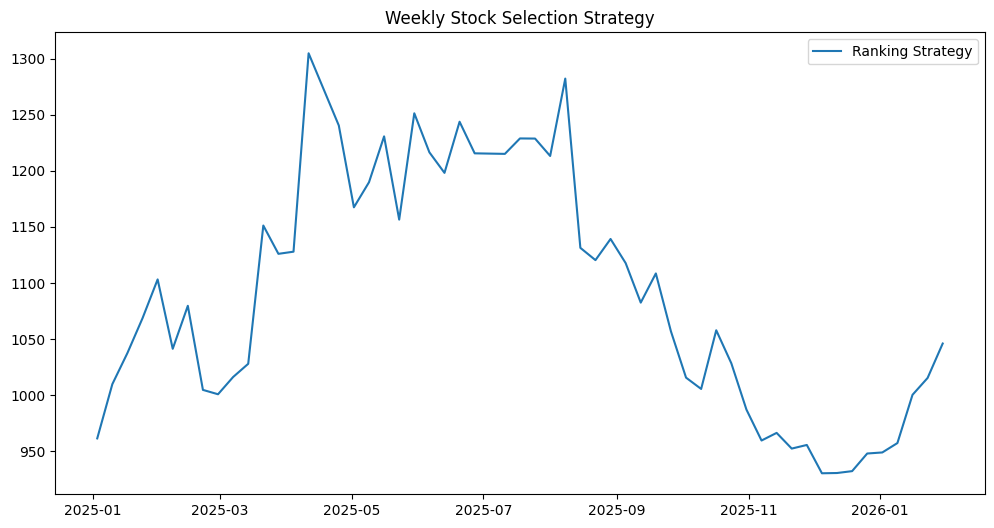

In [207]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(strategy_cum, label="Ranking Strategy")
plt.title("Weekly Stock Selection Strategy")
plt.legend()
plt.show()

Implemented a weekly ranking system by selecting the stock with the highest predicted return, enabling dynamic portfolio allocation and evaluation through backtesting. 

Ranking Accuracy

In [208]:
print(predictions_all.dtypes)

AAPL         float64
Top_Stock     object
dtype: object


In [209]:
predictions_all = predictions_all.apply(pd.to_numeric, errors='coerce')

In [214]:
common_dates = predictions_all.index.intersection(actual_returns.index)

predictions_all = predictions_all.loc[common_dates]
actual_returns = actual_returns.loc[common_dates]

In [215]:
correct = []
dates = []

for date in predictions_all.index:
    
    pred_best = predictions_all.loc[date].idxmax()
    actual_best = actual_returns.loc[date].idxmax()
    
    correct.append(1 if pred_best == actual_best else 0)
    dates.append(date)

ranking_df = pd.DataFrame({
    "Date": dates,
    "Correct": correct
})

ranking_df.set_index("Date", inplace=True)

ranking_accuracy = ranking_df['Correct'].mean()

print("Overall Ranking Accuracy:", ranking_accuracy)

Overall Ranking Accuracy: 0.2


Cumulative Ranking Accuracy Over Time

In [216]:
correct = []
dates = []

for date in predictions_all.index:
    
    pred_best = predictions_all.loc[date].idxmax()
    actual_best = actual_returns.loc[date].idxmax()
    
    correct.append(1 if pred_best == actual_best else 0)
    dates.append(date)

ranking_df = pd.DataFrame({
    "Date": dates,
    "Correct": correct
}).set_index("Date")

ranking_accuracy = ranking_df['Correct'].mean()

print("Overall Ranking Accuracy:", ranking_accuracy)

Overall Ranking Accuracy: 0.2


Daily/Weekly Correct Prediction

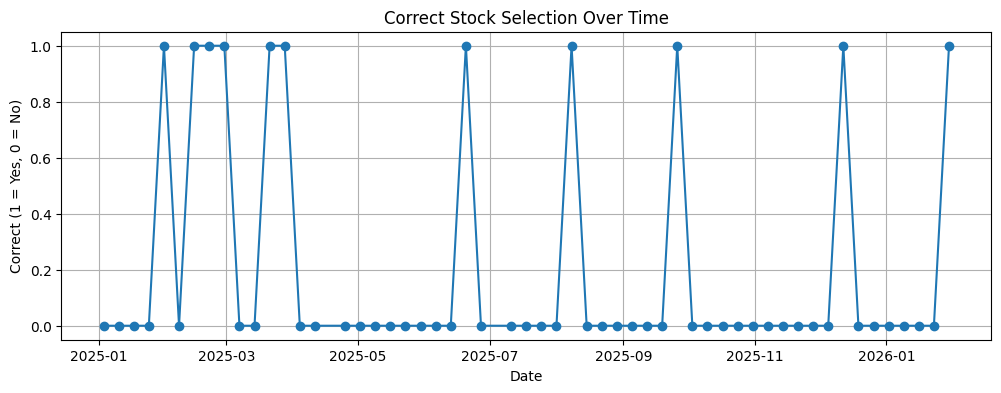

In [217]:
plt.figure(figsize=(12,4))

plt.plot(ranking_df.index, ranking_df['Correct'], marker='o')

plt.title("Correct Stock Selection Over Time")
plt.xlabel("Date")
plt.ylabel("Correct (1 = Yes, 0 = No)")
plt.grid()

plt.show()

Accuracy Distribution

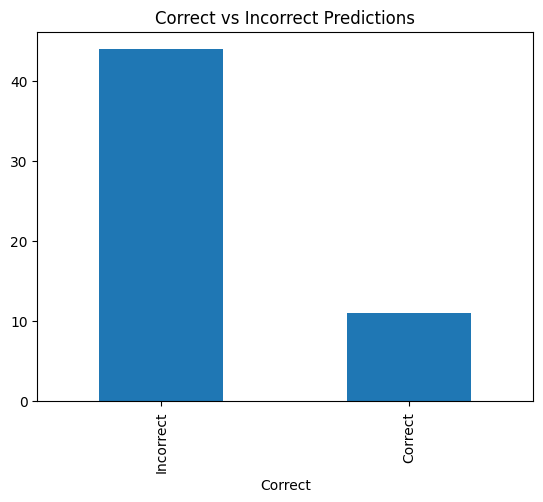

In [218]:
ranking_df['Correct'].value_counts().plot(kind='bar')

plt.title("Correct vs Incorrect Predictions")
plt.xticks([0,1], ["Incorrect", "Correct"])
plt.show()

The cumulative ranking accuracy plot demonstrates the model’s ability to correctly identify the best-performing stock over time, providing a direct measure of decision-making effectiveness relative to the target benchmark.

Implemented ARIMAX with feature engineering and walk-forward validation across multiple stocks, built a ranking and backtesting system, evaluated performance using MAE, RMSE, and directional accuracy, and generated a unified prediction dataset.